In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.svm import SVC

In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Exp 9 , 10/mitbih_train.csv', header=None)
test_df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Exp 9 , 10/mitbih_test.csv', header=None)
df_normal = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Exp 9 , 10/ptbdb_normal.csv', header=None)
df_abnormal = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Exp 9 , 10/ptbdb_abnormal.csv', header=None)

In [4]:
df_normal[187] = 0
df_abnormal[187] = 1

In [5]:
df_combined = pd.concat([df_normal, df_abnormal], axis=0)
X = df_combined.iloc[:, :-1].values
y = df_combined.iloc[:, -1].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)


In [8]:

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [9]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.80      0.84      0.82       809
           1       0.94      0.92      0.93      2102

    accuracy                           0.90      2911
   macro avg       0.87      0.88      0.87      2911
weighted avg       0.90      0.90      0.90      2911



In [10]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")

Accuracy:  0.8952
Precision: 0.9355
Recall:    0.9182
F1-Score:  0.9268


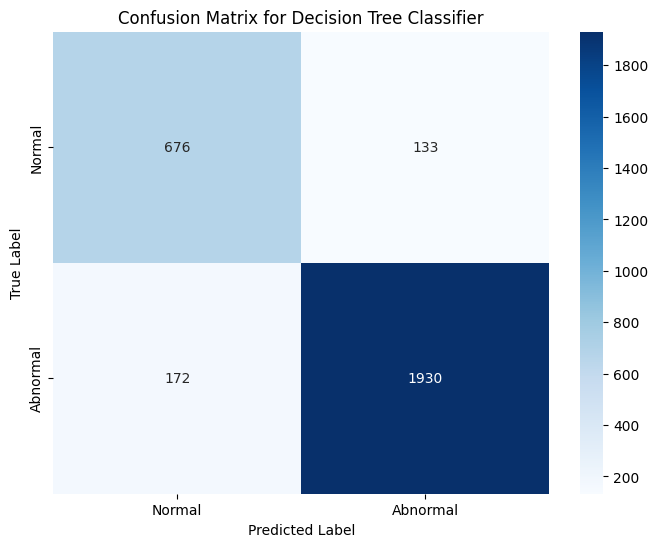

In [11]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', n_jobs=-1, random_state=42)

In [13]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [14]:
y_pred_rf = rf_model.predict(X_test)

In [15]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.97      0.92      0.95       809
           1       0.97      0.99      0.98      2102

    accuracy                           0.97      2911
   macro avg       0.97      0.96      0.96      2911
weighted avg       0.97      0.97      0.97      2911



In [16]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

Accuracy:  0.9705
Precision: 0.9701
Recall:    0.9895
F1-Score:  0.9797


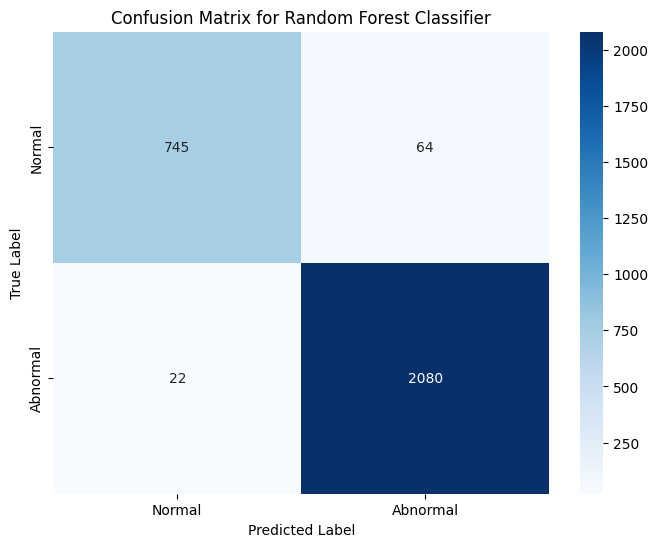

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [18]:
svm_model = SVC(random_state=42)

In [19]:
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [20]:
y_pred_svm = svm_model.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.77      0.81       809
           1       0.91      0.95      0.93      2102

    accuracy                           0.90      2911
   macro avg       0.89      0.86      0.87      2911
weighted avg       0.90      0.90      0.90      2911



In [22]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm):.4f}")

Accuracy:  0.9024
Precision: 0.9139
Recall:    0.9548
F1-Score:  0.9339


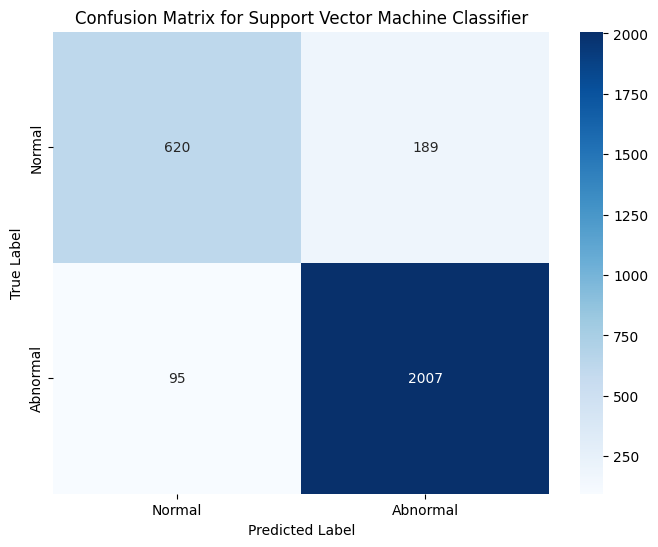

In [23]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix for Support Vector Machine Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [24]:
voting_classifier = VotingClassifier(estimators=[
    ('dt', DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, criterion='gini', n_jobs=-1, random_state=42)),
    ('svm', SVC(random_state=42, probability=True))
], voting='soft', n_jobs=-1)

In [26]:
voting_classifier.fit(X_train, y_train)

VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=10,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_jobs=-1,
                                                     random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [27]:
y_pred_voting = voting_classifier.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       809
           1       0.96      0.97      0.96      2102

    accuracy                           0.94      2911
   macro avg       0.93      0.93      0.93      2911
weighted avg       0.94      0.94      0.94      2911



In [30]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_voting, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_voting):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_voting):.4f}")

Accuracy:  0.9443
Precision: 0.9567
Recall:    0.9667
F1-Score:  0.9617


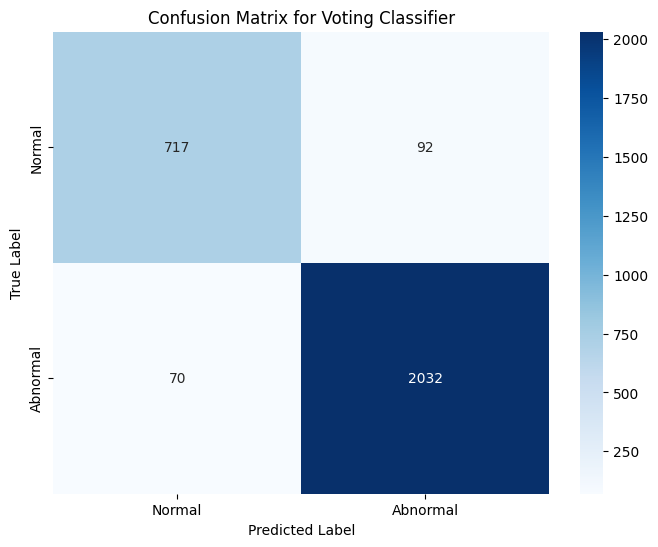

In [29]:
cm_voting = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix for Voting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

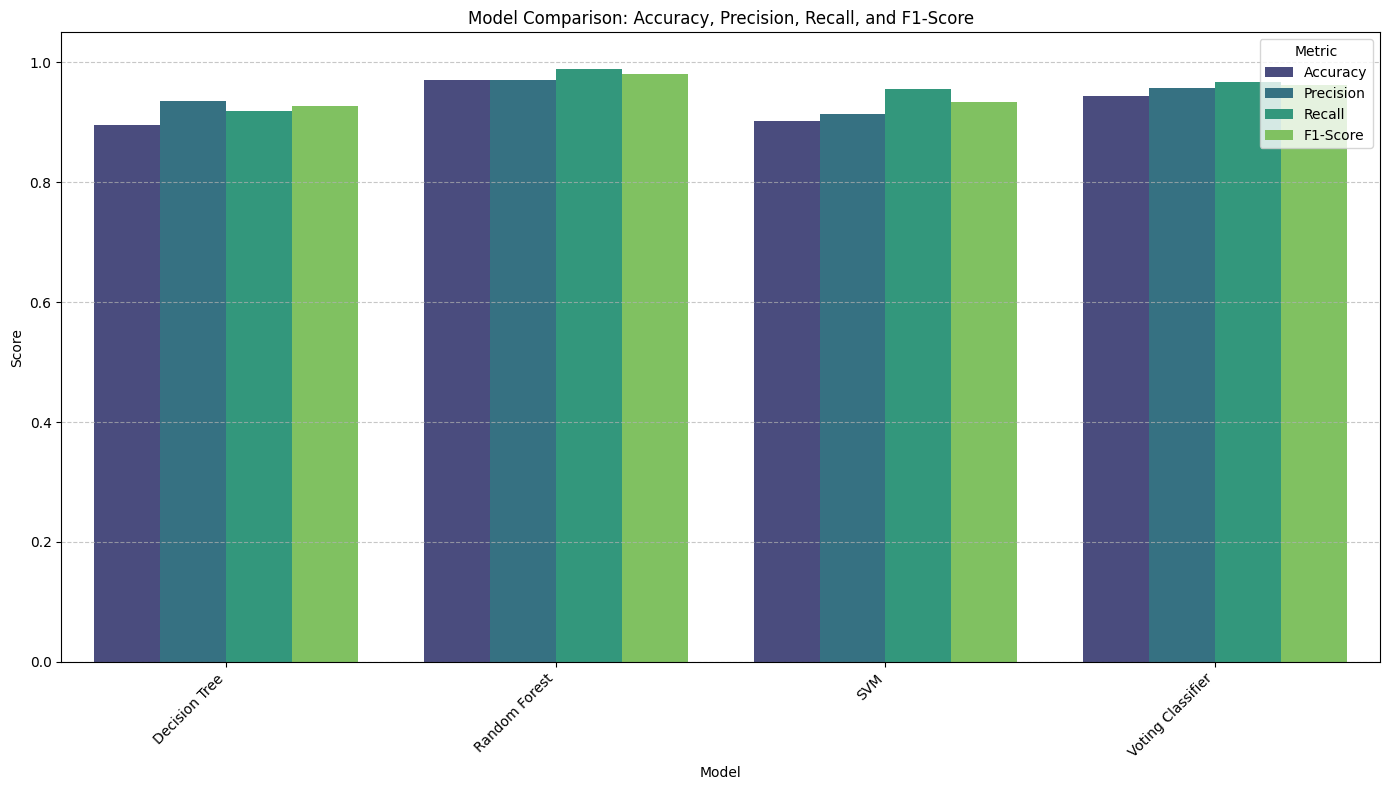

In [33]:
models = ['Decision Tree', 'Random Forest', 'SVM', 'Voting Classifier']
accuracy_scores = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_voting)
]
precision_scores = [
    precision_score(y_test, y_pred_dt, zero_division=0),
    precision_score(y_test, y_pred_rf, zero_division=0),
    precision_score(y_test, y_pred_svm, zero_division=0),
    precision_score(y_test, y_pred_voting, zero_division=0)
]
recall_scores = [
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_voting)
]
f1_scores = [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_voting)
]

metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Model Comparison: Accuracy, Precision, Recall, and F1-Score')
plt.ylabel('Score')
plt.ylim(0.0, 1.05) # Set y-axis limit from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Define the filename for the pickle file
filename = 'voting_classifier_model.pkl'

# Save the model to disk
with open(filename, 'wb') as file:
    pickle.dump(voting_classifier, file)

print(f"Model saved successfully to {filename}")